# Decoder-only Transformer trained on FineWeb-Edu
## Baseline configuration with GPT-2 BPE tokenizer

In [108]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import math
import time
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from utils import generate_positional_encoding, display_num_param, get_epoch_batches, load_eval_buffer

In [109]:
device = torch.device("cuda")
print(device)
if torch.cuda.is_available():
    print('cuda available with GPU:',torch.cuda.get_device_name(0))

cuda
cuda available with GPU: NVIDIA GeForce RTX 5080


## Tokenizer
Swap this block to test different tokenizers.  
The rest of the pipeline reads `tokenizer.vocab_size` and `tokenizer.eos_token_id`.

In [110]:
# --- Tokenizer (swap this block for ablation experiments) ---
tokenizer = AutoTokenizer.from_pretrained("gpt2")
vocab_size = tokenizer.vocab_size  # 50257
eos_token_id = tokenizer.eos_token_id  # 50256
print(f"Tokenizer: {tokenizer.__class__.__name__}")
print(f"Vocabulary size: {vocab_size}")
print(f"EOS token id: {eos_token_id}")

Tokenizer: GPT2Tokenizer
Vocabulary size: 50257
EOS token id: 50256


## Model architecture
Identical to the template transformer — sinusoidal PE, pre-norm decoder blocks, ReLU MLP.

In [111]:
# One MHA block
class MultipleAttentionHead(nn.Module):
    def __init__(self, d, num_heads, dropout):
        super().__init__()
        d_head = d // num_heads # dim_head = d // num_heads, usually dimension per head is 64
        assert d == d_head * num_heads # check divisibility
        self.WQ = nn.Linear(d, d, bias=False)
        self.WK = nn.Linear(d, d, bias=False)
        self.WV = nn.Linear(d, d, bias=False)
        self.WO = nn.Linear(d, d) # combination layer
        self.dropout_p = dropout
        self.num_heads = num_heads
        self.d_head = d_head


    def forward(self, H): # size(H)=[batch_size, seq_length, d]
        batch, seq_len, _ = H.shape
        # Compute QKV for all heads in parallel and split into individual heads
        Q = self.WQ(H).reshape(batch, seq_len, self.num_heads, self.d_head) # (batch, seq_len, num_heads, d_head)
        K = self.WK(H).reshape(batch, seq_len, self.num_heads, self.d_head) # (batch, seq_len, num_heads, d_head)
        V = self.WV(H).reshape(batch, seq_len, self.num_heads, self.d_head) # (batch, seq_len, num_heads, d_head)
        # Transpose for shape that attn expects
        Q = Q.transpose(1,2) # (batch, num_heads, seq_len, d_head)
        K = K.transpose(1,2) # (batch, num_heads, seq_len, d_head)
        V = V.transpose(1,2) # (batch, num_heads, seq_len, d_head)
        # Compute MHA in parallel
        attn_out = F.scaled_dot_product_attention(Q, K, V, is_causal=True, dropout_p=self.dropout_p if self.training else 0.0)
        attn_out = attn_out.transpose(1,2) # transpose back
        attn_out = attn_out.reshape(batch, seq_len, self.d_head * self.num_heads) # Combine outputs of all attn heads
        H = self.WO(attn_out)
        
        return H

In [112]:
# One transformer block
class TransformerBlock(nn.Module):
    def __init__(self, d, num_heads, dropout):
        super().__init__()
        self.LN_MHA = nn.LayerNorm(d)
        self.LN_MLP = nn.LayerNorm(d)
        self.MHA = MultipleAttentionHead(d, num_heads, dropout)
        self.MLP = nn.Sequential(nn.Linear(d,4*d), nn.ReLU(), nn.Dropout(dropout), nn.Linear(4*d,d))
        self.drop_attn = nn.Dropout(dropout)
        self.drop_mlp = nn.Dropout(dropout)
    def forward(self, H): # size=[batch_size, seq_length, d]
        # Multiple Attention Heads w/ layer normalization (LN), residual connection (RC) 
        H = H + self.drop_attn(self.MHA(self.LN_MHA(H)))
        # MLP w/ layer normalization (LN), residual connection (RC) 
        H = H + self.drop_mlp(self.MLP(self.LN_MLP(H)))
        return H # size=[batch_size, seq_length, d]

In [113]:
# Transformer decoder before MLP
class Transformer_decoder(nn.Module):
    def __init__(self, d, num_heads, num_blocks, seq_length, dropout):
        super().__init__()
        self.TR_Blocks = nn.ModuleList([ TransformerBlock(d, num_heads, dropout) for _ in range(num_blocks) ])
        self.final_norm = nn.LayerNorm(d)
    def forward(self, batch_seq, pos_enc):
        H = batch_seq.transpose(1,0) # size=[batch_size, seq_length, d]
        batch_size = H.size(0); batch_len = H.size(1)
        # Add positional encoding  
        pos_enc = pos_enc.unsqueeze(dim=0) # size=[1,          seq_length, d]
        H = H + pos_enc                     # size=[batch_size, seq_length, d]
        # Apply transformer blocks 
        for TR_Block in self.TR_Blocks:
            H = TR_Block(H)
        # Output
        H = self.final_norm(H)
        H = H.permute(1,0,2)  # size=[batch_length, batch_size, d]
        return H # return prediction scores for next token

In [114]:
# End to end decoder only transformer (naive, without any funny tricks)
class ANN(nn.Module):
    
    def __init__(self, d, num_heads, num_blocks, seq_length, dropout):
        super(ANN, self).__init__()
        self.decoder = Transformer_decoder(d, num_heads, num_blocks, seq_length, dropout)
    
    def forward(self, g_seq , pos ):
        h_dec_seq = self.decoder( g_seq , pos )
        return h_dec_seq 
    

class attention_net(nn.Module):

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0, std=0.02)
        elif isinstance(module, nn.LayerNorm):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)


    def __init__(self, vocab_size, d, num_heads, num_blocks, seq_length, dropout):
        super(attention_net, self).__init__()  
        self.layer1 = nn.Embedding(vocab_size, d)
        self.layer2 = ANN(d, num_heads, num_blocks, seq_length, dropout)
        self.layer3 = nn.Linear(d, vocab_size, bias=False)
        self.layer3.weight = self.layer1.weight
        self.apply(self._init_weights)
        residual_std = 0.02 / math.sqrt(2 * num_blocks)
        for block in self.layer2.decoder.TR_Blocks:
            nn.init.normal_(block.MHA.WO.weight, mean=0, std=residual_std)
            nn.init.normal_(block.MLP[3].weight, mean=0, std=residual_std)




    def forward(self, word_seq, pos ):
        g_seq     =   self.layer1( word_seq ) # size=(seq_length, bs, hidden_dim) 
        h_seq     =   self.layer2( g_seq , pos ) # size=(seq_length, bs, hidden_dim) 
        score_seq =   self.layer3( h_seq ) # size=(seq_length, bs, vocab_size)
        return score_seq 

## Hyperparameters & model instantiation

In [ ]:
# hyperparameters
bs = 32
hidden_size = 384
num_heads = 6
num_blocks = 6
dropout = 0.1
seq_length = 512
tokens_per_epoch = 2_000_000  # how many tokens per training epoch
num_epochs = 4
peak_lr = 3e-4
accumulation_steps = 4

pos = generate_positional_encoding(seq_length, hidden_size).to(device)

net = attention_net(vocab_size, hidden_size, num_heads, num_blocks, seq_length, dropout)
print(net)
display_num_param(net)
net = net.to(device)

attention_net(
  (layer1): Embedding(50257, 384)
  (layer2): ANN(
    (decoder): Transformer_decoder(
      (TR_Blocks): ModuleList(
        (0-5): 6 x TransformerBlock(
          (LN_MHA): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
          (LN_MLP): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
          (MHA): MultipleAttentionHead(
            (WQ): Linear(in_features=384, out_features=384, bias=False)
            (WK): Linear(in_features=384, out_features=384, bias=False)
            (WV): Linear(in_features=384, out_features=384, bias=False)
            (WO): Linear(in_features=384, out_features=384, bias=True)
          )
          (MLP): Sequential(
            (0): Linear(in_features=384, out_features=1536, bias=True)
            (1): ReLU()
            (2): Dropout(p=0.1, inplace=False)
            (3): Linear(in_features=1536, out_features=384, bias=True)
          )
          (drop_attn): Dropout(p=0.1, inplace=False)
          (drop_mlp): Dropout(p=0.1,

In [116]:

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(net.parameters(), lr=peak_lr, weight_decay=0.01)
total_steps = num_epochs * (tokens_per_epoch // (bs * seq_length)) // accumulation_steps
warmup_steps = total_steps // 20
min_lr = peak_lr / 10

def calc_multiplier(step):
    if step < warmup_steps:
        return step/warmup_steps # during warmup, ramp lr from 0 to 1 linearly
    progress = (step - warmup_steps) / (total_steps - warmup_steps)
    return min_lr/peak_lr + (1 - min_lr/peak_lr) * 0.5 * (1 + math.cos(math.pi * progress)) # after warmup, calc lr using cosine decay

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=calc_multiplier)

In [117]:
# pre-load eval buffer (streams ~500K tokens from a different region of FineWeb-Edu)
print("Loading eval buffer...")
eval_data = load_eval_buffer(tokenizer, bs, eos_token_id)
print(f"Eval buffer shape: {eval_data.shape}")

Loading eval buffer...


Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1368 > 1024). Running this sequence through the model will result in indexing errors


Eval buffer shape: torch.Size([15625, 32])


In [118]:
# eval helper
@torch.no_grad()
def eval_on_test_set():
    net.eval()
    running_loss = 0
    num_batches = 0
    num_steps = eval_data.size(0) - seq_length

    for count in range(0, num_steps, seq_length):
        minibatch_data  = eval_data[count   : count+seq_length]
        minibatch_label = eval_data[count+1 : count+seq_length+1]

        minibatch_data  = minibatch_data.to(device)
        minibatch_label = minibatch_label.to(device)

        with torch.autocast("cuda", dtype=torch.bfloat16):
            scores = net(minibatch_data, pos)

            minibatch_label = minibatch_label.view(bs * seq_length)
            scores = scores.view(bs * seq_length, vocab_size)

            loss = criterion(scores, minibatch_label)

        running_loss += loss.item()
        num_batches += 1

    total_loss = running_loss / num_batches
    print(f'eval: exp(loss) = {math.exp(total_loss):.2f}')
    net.train()
    return total_loss

## Training

In [119]:
# init tracking lists
train_ppls = []
eval_ppls = []
tokens_per_sec = []

# training loop
checkpoint_path = "best_model.pt"
best_loss = float('inf')
prev_elapsed = 0

start = time.time()
for epoch in range(num_epochs):

    running_loss = 0
    num_batches = 0
    step = 0
    net.train()
    optimizer.zero_grad()

    for minibatch_data, minibatch_label in get_epoch_batches(
            tokens_per_epoch, bs, seq_length, tokenizer, eos_token_id, seed=epoch):

        minibatch_data  = minibatch_data.to(device)
        minibatch_label = minibatch_label.to(device)
        with torch.autocast("cuda", dtype=torch.bfloat16):
            # forward pass: size=(seq_length, bs, vocab_size)
            scores = net(minibatch_data, pos)

            # reshape for cross-entropy
            scores = scores.view(bs * seq_length, vocab_size)
            minibatch_label = minibatch_label.view(bs * seq_length)

            loss = criterion(scores, minibatch_label)
            loss = loss / accumulation_steps

        loss.backward()
        running_loss += loss.item() * accumulation_steps  # unscale for logging
        num_batches += 1
        step += 1

        if step % accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

    # flush leftover accumulated gradients
    if step % accumulation_steps != 0:
        torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    total_loss = running_loss / num_batches
    elapsed = time.time() - start

    epoch_tokens = num_batches * bs * seq_length
    epoch_time = elapsed - prev_elapsed
    tps = epoch_tokens / epoch_time
    prev_elapsed = elapsed

    current_lr = optimizer.param_groups[0]['lr']
    print(f'\nepoch={epoch}\t time={elapsed:.1f}\t lr={current_lr:.6f}\t exp(loss)={math.exp(total_loss):.2f}\t tok/s={tps:.0f}')
    eval_loss = eval_on_test_set()

    train_ppls.append(math.exp(total_loss))
    eval_ppls.append(math.exp(eval_loss))
    tokens_per_sec.append(tps)

    if eval_loss < best_loss:
        best_loss = eval_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'eval_loss': eval_loss,
        }, checkpoint_path)
        print(f'  -> saved checkpoint (eval ppl = {math.exp(eval_loss):.2f})')

print(f'\nPeak GPU memory: {torch.cuda.max_memory_allocated() / 1024**3:.2f} GB')

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]


epoch=0	 time=19.4	 lr=0.000270	 exp(loss)=11153.40	 tok/s=102928
eval: exp(loss) = 2958.47
  -> saved checkpoint (eval ppl = 2958.47)


Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]


epoch=1	 time=37.5	 lr=0.000172	 exp(loss)=2215.31	 tok/s=110813
eval: exp(loss) = 2262.47
  -> saved checkpoint (eval ppl = 2262.47)


Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]


epoch=2	 time=58.5	 lr=0.000070	 exp(loss)=2199.44	 tok/s=95037
eval: exp(loss) = 2188.47
  -> saved checkpoint (eval ppl = 2188.47)


Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]


epoch=3	 time=76.2	 lr=0.000030	 exp(loss)=2075.81	 tok/s=113030
eval: exp(loss) = 2176.42
  -> saved checkpoint (eval ppl = 2176.42)

Peak GPU memory: 15.53 GB


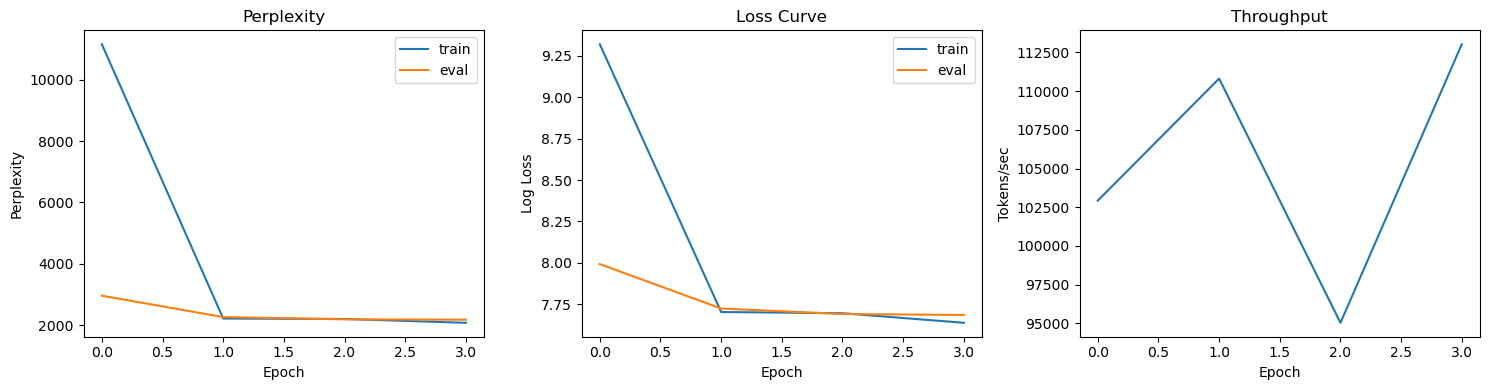

Parameters: 29,939,328
Peak GPU memory: 15.53 GB


In [120]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_ppls, label='train')
axes[0].plot(eval_ppls, label='eval')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Perplexity')
axes[0].legend()
axes[0].set_title('Perplexity')

axes[1].plot([math.log(p) for p in train_ppls], label='train')
axes[1].plot([math.log(p) for p in eval_ppls], label='eval')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Log Loss')
axes[1].legend()
axes[1].set_title('Loss Curve')

axes[2].plot(tokens_per_sec)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Tokens/sec')
axes[2].set_title('Throughput')

plt.tight_layout()
plt.show()

print(f'Parameters: {sum(p.numel() for p in net.parameters() if p.requires_grad):,}')
print(f'Peak GPU memory: {torch.cuda.max_memory_allocated() / 1024**3:.2f} GB')

## Text generation
Autoregressive generation: feed the prompt, sample one token, append it, repeat.  
Supports **greedy**, **top-k**, and **top-p (nucleus)** decoding with temperature scaling.

In [121]:
# load best checkpoint for inference
checkpoint = torch.load(checkpoint_path, weights_only=False)
net.load_state_dict(checkpoint['model_state_dict'])
net.eval()
print(f"Loaded checkpoint from epoch {checkpoint['epoch']}, eval ppl = {math.exp(checkpoint['eval_loss']):.2f}")

Loaded checkpoint from epoch 3, eval ppl = 2176.42


In [122]:
@torch.no_grad()
def generate(prompt, max_new_tokens=100, temperature=1.0, top_k=0, top_p=0.0):
    """
    Autoregressive text generation from a prompt string.
    
    Args:
        prompt:          seed text
        max_new_tokens:  how many tokens to generate
        temperature:     >1 = more random, <1 = more focused, 1 = unchanged
        top_k:           if >0, only sample from the top-k most likely tokens
        top_p:           if >0, nucleus sampling — sample from smallest set with cumulative prob >= top_p
    """
    net.eval()
    token_ids = tokenizer.encode(prompt)

    for _ in range(max_new_tokens):
        # truncate context to seq_length if it grows too long
        context = token_ids[-seq_length:]
        x = torch.LongTensor(context).unsqueeze(1).to(device)  # (ctx_len, 1)
        pos_enc = generate_positional_encoding(x.size(0), hidden_size).to(device)

        with torch.autocast("cuda", dtype=torch.bfloat16):
            # forward pass with batch_size=1
            scores = net(x, pos_enc)       # (ctx_len, 1, vocab_size)
        logits = scores[-1, 0, :].float()  # last position logits, (vocab_size,)

        # temperature scaling
        if temperature != 1.0:
            logits = logits / temperature

        # top-k filtering
        if top_k > 0:
            topk_vals, _ = torch.topk(logits, top_k)
            logits[logits < topk_vals[-1]] = float('-inf')

        # top-p (nucleus) filtering
        if top_p > 0.0:
            sorted_logits, sorted_idx = torch.sort(logits, descending=True)
            cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=0), dim=0)
            # remove tokens with cumulative prob above the threshold (keep first token above)
            remove_mask = cumulative_probs - F.softmax(sorted_logits, dim=0) >= top_p
            sorted_logits[remove_mask] = float('-inf')
            logits = sorted_logits.scatter(0, sorted_idx, sorted_logits)

        probs = F.softmax(logits, dim=0)

        # greedy vs sampling
        if temperature == 0 or (top_k == 0 and top_p == 0.0):
            next_token = torch.argmax(probs).item()
        else:
            next_token = torch.multinomial(probs, 1).item()

        # stop on EOS
        if next_token == eos_token_id:
            break

        token_ids.append(next_token)

    return tokenizer.decode(token_ids)

In [123]:
# sample prompts
prompts = [
    "My social security number is"
]

for p in prompts:
    print("=" * 70)
    print(f"PROMPT: {p}")
    print("-" * 70)

    print("\n[Greedy]")
    print(generate(p, max_new_tokens=100))

    print("\n[Top-k=50, temp=0.8]")
    print(generate(p, max_new_tokens=100, temperature=0.8, top_k=50))

    print("\n[Nucleus p=0.9, temp=0.9]")
    print(generate(p, max_new_tokens=100, temperature=0.9, top_p=0.9))
    print()

PROMPT: My social security number is
----------------------------------------------------------------------

[Greedy]
My social security number is the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the

[Top-k=50, temp=0.8]
My social security number is the the in the,� a the at is the for,. by. to
,,.,�. the and the is to, the, and
 it the� are,. can that� you a
.� the, the the the, and. of in is, that the the, to be.- the from,.- and or
, the have of. a the is a�.� to, a of was, it to, of a the

[Nucleus p=0.9, temp=0.9]
My social security number is,, this by; therefore lifestyle attack).R of will have to PhIt a as, at the. aOne of tos of was Tte